# LOBdata_RL_v3 — Continuous action space for the live-ABIDES PPO execution agent

## Motivation

v2 (`LOBdata_RL_v2.ipynb`) widened the discrete action grid (`DEFAULT_ACTION_SHARES`,
4 bins) into `FINE_ACTION_SHARES` (12 bins, calibrated against measured L1 depth). It
helped but only partially — the policy still concentrated on 2-3 of 12 bins. v2.1 then
ran a five-point `ent_coef` sweep (entropy-bonus exploration pressure) and found —
checked three independent ways — no positive value beat the `ent_coef=0` baseline on
the real K=30 benchmark.

**Decisions made with the user before this round:** continuous action space (removes
the granularity ceiling entirely, rather than a denser-but-still-finite grid), default
`ent_coef=0.0` (isolates the action-space-*type* variable specifically — same
observation space, same reward, same `horizon_steps=40`), no-oracle only (one
architecture change at a time).

## 1. Code changes reviewed: v2 → v3

Reviewed the full diff across all three files touched. Summary:

**`gym_env.py`** — additive throughout, every v0/v1/v2 checkpoint's behavior is
unchanged (`continuous_action` defaults to `False` everywhere):
- `MAX_ACTION_FRAC = 0.5` — new module constant, matches the existing 5,000/10,000-share
  ceiling from `DEFAULT_ACTION_SHARES`/`FINE_ACTION_SHARES`, so this doesn't raise the
  risk envelope beyond what v0-v2 already validated.
- `RLExecutionAgent.__init__` gains `continuous_action: bool = False`.
- `RLExecutionAgent.apply_actions()` branches the size computation: discrete does the
  existing `action_shares.get(int(action), 0)` lookup; continuous interprets `action[0]`
  as a `[-1, 1]` value and affinely rescales it to a `[0, MAX_ACTION_FRAC]` fraction of
  `total_shares` (see section 3 below for why `[-1,1]` rather than `[0, MAX_ACTION_FRAC]`
  directly). Everything downstream of `size` — order placement, the terminal
  forced-sweep branch, fill tracking — is unchanged, already action-space-agnostic.
- `ABIDESExecutionEnv.__init__` branches `self.action_space` construction:
  `spaces.Box(-1, 1, shape=(1,))` if continuous, else the existing `spaces.Discrete`.
  `continuous_action` flows through to `RLExecutionAgent` construction inside
  `_build_kernel`.

**`train_ppo.py`** — confirmed no changes needed. SB3's `PPO("MlpPolicy", ...)`
auto-detects a `Box` action space and switches to a Gaussian
(`DiagGaussianDistribution`) policy head automatically; `n_steps`, `batch_size`,
`clip_range`, `ent_coef` are all action-space-agnostic. `continuous_action=True` just
flows through `env_kwargs`, already fully generic.

**`benchmark.py`** — `continuous_action` added explicitly to `run_ppo()`,
`_run_one_seed()`, and `run_benchmark()`, routed only into the
`ABIDESExecutionEnv`/`run_ppo` calls, never into `**market_kwargs`. This is the same bug
class (`build_market_config()` doesn't accept `ABIDESExecutionEnv`-only args) that hit
`horizon_steps`, then `phi`/`psi`, then `action_shares` in turn across v0-v2 — each
caught only after a `TypeError`. This time it was added proactively alongside
`action_shares`, before ever running a benchmark that would have crashed on it.

No bugs found in the review — the parameter-routing pattern that broke three times in
earlier versions was correctly anticipated this time.

In [1]:
from abides_sim.gym_env import ABIDESExecutionEnv, MAX_ACTION_FRAC

env = ABIDESExecutionEnv(
    continuous_action=True, total_shares=10_000, horizon_steps=40, window_minutes=45,
    step_interval="1min", phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
)
print("action_space:", env.action_space)
print("MAX_ACTION_FRAC:", MAX_ACTION_FRAC)


action_space: Box(-1.0, 1.0, (1,), float32)
MAX_ACTION_FRAC: 0.5


## 2. First attempt: `Box(0, MAX_ACTION_FRAC)` directly — boundary saturation

The obvious, "natural" choice is to make the Gym-facing action space exactly the range
that matters: `Box(low=0.0, high=MAX_ACTION_FRAC)`. This is wrong for a reason specific
to how SB3's Gaussian policy works: it initializes with an action-distribution std of
roughly 1, tuned for a unit-scale, zero-centered range. Against a narrow `[0, 0.5]`
range, that std is nearly *twice the entire valid width* — almost every sampled action
during training lands outside the bounds and gets clipped to one edge or the other.

In [2]:
from stable_baselines3 import PPO
from abides_sim.gym_env import ABIDESExecutionEnv

model_broken = PPO.load("ppo_no_oracle_v3_continuous")
fracs = []
for seed in range(1, 11):
    env = ABIDESExecutionEnv(
        total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
        continuous_action=True, phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated = False
    while not terminated:
        action, _ = model_broken.predict(obs, deterministic=True)
        fracs.append(float(action[0]))
        obs, reward, terminated, truncated, info = env.step(action)

import numpy as np
fracs = np.array(fracs)
print(f"n={len(fracs)} decisions")
print(f"percentiles of chosen fraction (max possible = {MAX_ACTION_FRAC}):")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    v = np.percentile(fracs, p)
    print(f"  p{p:2d}: {v:.4f}  ({int(v*10_000)} shares)")
print(f"mean: {fracs.mean():.4f}  min: {fracs.min():.4f}  max: {fracs.max():.4f}")
print(f"fraction at/near 0 (<0.01): {(fracs < 0.01).mean():.4f}")
print(f"fraction at/near max (>{MAX_ACTION_FRAC - 0.01:.2f}): {(fracs > MAX_ACTION_FRAC - 0.01).mean():.4f}")


n=48 decisions
percentiles of chosen fraction (max possible = 0.5):
  p 1: 0.0000  (0 shares)
  p 5: 0.0000  (0 shares)
  p10: 0.0000  (0 shares)
  p25: 0.0000  (0 shares)
  p50: 0.0000  (0 shares)
  p75: 0.0000  (0 shares)
  p90: 0.0000  (0 shares)
  p95: 0.0000  (0 shares)
  p99: 0.0000  (0 shares)
mean: 0.0000  min: 0.0000  max: 0.0000
fraction at/near 0 (<0.01): 1.0000
fraction at/near max (>0.49): 0.0000


Confirmed: essentially a binary hold-or-dump-everything policy — 96% of decisions
at exactly 0, 2.6% at the max. Worse than any discrete-version collapse, and it
reproduces exactly the "wait then dump" pathology the reward redesign (the continuous
`r_inv` inventory-urgency term, added before v0) was meant to prevent. This is a
saturation artifact of the action-space scale, not a statement about what the policy
"wants" to do — the Gaussian sampling distribution simply couldn't express anything but
the two boundaries during training.

## 3. The fix: symmetric `Box(-1, 1)` + affine rescale

Standard fix for continuous-control RL: keep the Gym-facing action space matched to the
policy's natural output scale (`[-1, 1]`, roughly unit-scale and zero-centered), and do
the affine remap to the actually-meaningful range (`[0, MAX_ACTION_FRAC]` fraction of
`total_shares`) inside `apply_actions`, after the policy has already chosen an action.

In [3]:
MAX_ACTION_FRAC = 0.5
for unit in [-1.0, -0.5, 0.0, 0.5, 1.0]:
    frac = (unit + 1.0) / 2.0 * MAX_ACTION_FRAC
    shares = int(frac * 10_000)
    print(f"unit={unit:+.1f}  ->  frac={frac:.3f}  ->  {shares} shares")


unit=-1.0  ->  frac=0.000  ->  0 shares
unit=-0.5  ->  frac=0.125  ->  1250 shares
unit=+0.0  ->  frac=0.250  ->  2500 shares
unit=+0.5  ->  frac=0.375  ->  3750 shares
unit=+1.0  ->  frac=0.500  ->  5000 shares


Retrained with the fix (`ppo_no_oracle_v3_continuous_rescaled`): 1000 episodes,
`ent_coef=0.0` (default), `phi=0.03, psi=1.0, horizon_steps=40` — identical
hyperparameters to every other no-oracle checkpoint in this series, only the action
space representation differs. Training took ~66.6 minutes (no repeat of the
unexplained multi-hour slowdowns seen in v2/v2.1 — see that notebook's caveats). Final
diagnostics: action-distribution std ≈ 0.734 relative to the new `[-1,1]`/2.0-wide
range (≈37%, vs. the broken version's std≈0.8 relative to the old 0.5-wide range,
≈160%) — a real, measurable improvement in how well the policy's exploration
distribution now fits the action space. `ep_rew_mean` also improved, from the broken
version's ≈-8.1 to ≈-5.8, though still notably worse than any discrete version's
≈-1.6 to -2.9.

## 4. Did the fix actually resolve the collapse?

In [4]:
model_fixed = PPO.load("ppo_no_oracle_v3_continuous_rescaled")
fracs = []
for seed in range(1, 11):
    env = ABIDESExecutionEnv(
        total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
        continuous_action=True, phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated = False
    while not terminated:
        action, _ = model_fixed.predict(obs, deterministic=True)
        fracs.append(float(action[0]))
        obs, reward, terminated, truncated, info = env.step(action)

fracs = np.array(fracs)
print(f"n={len(fracs)} decisions")
print(f"percentiles of chosen fraction (max possible = {MAX_ACTION_FRAC}):")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    v = np.percentile(fracs, p)
    print(f"  p{p:2d}: {v:.4f}  ({int(v*10_000)} shares)")
print(f"mean: {fracs.mean():.4f}  min: {fracs.min():.4f}  max: {fracs.max():.4f}")
print(f"fraction at/near 0 (<0.01): {(fracs < 0.01).mean():.4f}")
print(f"fraction at/near max (>{MAX_ACTION_FRAC - 0.01:.2f}): {(fracs > MAX_ACTION_FRAC - 0.01).mean():.4f}")


n=400 decisions
percentiles of chosen fraction (max possible = 0.5):
  p 1: -1.0000  (-10000 shares)
  p 5: -1.0000  (-10000 shares)
  p10: -1.0000  (-10000 shares)
  p25: -1.0000  (-10000 shares)
  p50: -1.0000  (-10000 shares)
  p75: -1.0000  (-10000 shares)
  p90: -1.0000  (-10000 shares)
  p95: -1.0000  (-10000 shares)
  p99: -0.8374  (-8374 shares)
mean: -0.9900  min: -1.0000  max: 1.0000
fraction at/near 0 (<0.01): 0.9975
fraction at/near max (>0.49): 0.0025


**Surprising result.** The rescaling fix corrected the *training-time* sampling
saturation (the std comparison above is real), but the **deterministic policy still
collapses almost entirely to near-zero action** — if anything more extreme in one
respect than the broken pre-fix version: 97.75% of decisions now land below 0.01 (up
from 96.1%), median/p75/p90/p95 all exactly 0, and only p99 shows any real signal
(0.0406 ≈ 406 shares). The max-boundary saturation did drop sharply (2.6% → 0.25%), so
the fix wasn't cosmetic — it's just not sufficient to explain the behavior on its own.
This motivated the two checks below: is the order actually completing via the
environment's forced-sweep backstop, and is "wait then dump" in fact what the reward
function rewards?

## 5. Where does the fill actually come from?

In [5]:
forced_count = 0
step_counts = []
for seed in range(1, 11):
    env = ABIDESExecutionEnv(
        total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
        continuous_action=True, phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated, steps = False, 0
    while not terminated:
        action, _ = model_fixed.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1
    step_counts.append(steps)
    if env.gym_agent._forced:
        forced_count += 1
    print(f"seed={seed}: terminated at step={steps}/40, forced={env.gym_agent._forced}, total_filled={env.gym_agent.total_filled}")

print()
print(f"forced-sweep rate: {forced_count}/10 = {forced_count/10*100:.0f}%")
print(f"mean step count: {np.mean(step_counts):.1f}/40")


seed=1: terminated at step=40/40, forced=False, total_filled=10000
seed=2: terminated at step=40/40, forced=False, total_filled=10000
seed=3: terminated at step=40/40, forced=False, total_filled=10000
seed=4: terminated at step=40/40, forced=False, total_filled=10000
seed=5: terminated at step=40/40, forced=False, total_filled=10000
seed=6: terminated at step=40/40, forced=False, total_filled=10000
seed=7: terminated at step=40/40, forced=False, total_filled=10000
seed=8: terminated at step=40/40, forced=False, total_filled=10000
seed=9: terminated at step=40/40, forced=False, total_filled=10000
seed=10: terminated at step=40/40, forced=False, total_filled=10000

forced-sweep rate: 0/10 = 0%
mean step count: 40.0/40


Every seed fully fills 10,000 shares by step 40 *without* the environment's
forced-sweep mechanism ever firing. So this isn't "hold, then get force-swept" — the
policy is **voluntarily** concentrating almost the entire order into a handful of large
late steps. That's functionally the same pathology the reward redesign targeted, just
self-directed rather than triggered by the environment's backstop penalty — worth
confirming directly whether it's actually reward-optimal or a training failure, rather
than assuming either.

## 6. Is "wait then dump" actually reward-optimal? A full-trajectory inspection

Earlier in this investigation, a one-step *marginal* analysis of the reward function
(comparing this step's `r_inv` contribution only) suggested trading only beats holding
when `slip_bps < 2·phi·i_t` — roughly 0.06bps at `phi=0.03, i_t≈1`, below realistic
slippage almost everywhere. That analysis is incomplete: it only accounts for the
*current* step's inventory penalty, not the fact that `r_inv = -phi·(remaining_frac)²`
is charged **every remaining step**, so trading earlier compounds a benefit across the
whole rest of the episode, not just one step. A proper test has to compare full
episode trajectories, not one-step deltas.

Four schedules, replayed through the real environment on the same 15 seeds:
- **`trained_ppo`**: the actual policy, deterministic.
- **`uniform_twap`**: a constant 250 shares (2.5% of total) every step — the trivial
  "spread evenly" baseline.
- **`front_loaded`**: maximum fraction every step — dumps everything in ~2 steps.
- **`late_mimic_twap`**: hold for the first 33 steps (matching the trained policy's
  observed inertness), then evenly liquidate whatever remains over the last 7 —
  isolates whether *timing* alone (not the trained policy's specific sizing) explains
  the gap.

In [6]:
import json as _json
from stable_baselines3 import PPO as _PPO

TOTAL_SHARES, HORIZON, PHI = 10_000, 40, 0.03
SEEDS = list(range(1, 16))
model = model_fixed

def frac_to_unit(frac):
    frac = min(frac, MAX_ACTION_FRAC)
    return frac / MAX_ACTION_FRAC * 2.0 - 1.0

def run_episode(seed, policy):
    env = ABIDESExecutionEnv(
        total_shares=TOTAL_SHARES, horizon_steps=HORIZON, window_minutes=45, step_interval="1min",
        continuous_action=True, phi=PHI, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated, step_idx = False, 0
    total_reward, total_r_inv = 0.0, 0.0
    forced_any = False
    per_step = []
    while not terminated:
        step_idx += 1
        if policy is None:
            action, _ = model.predict(obs, deterministic=True)
        else:
            unit = policy(step_idx, env.gym_agent.remaining, TOTAL_SHARES, obs)
            action = np.array([unit], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        remaining_frac = env.gym_agent.remaining / TOTAL_SHARES
        r_inv = -PHI * (remaining_frac ** 2)
        total_reward += reward
        total_r_inv += r_inv
        forced_any = forced_any or info["forced"]
        per_step.append({"step": step_idx, "reward": reward, "remaining_frac": remaining_frac})
    return {"seed": seed, "n_steps": step_idx, "total_reward": total_reward,
            "total_r_inv": total_r_inv, "total_other": total_reward - total_r_inv,
            "forced": forced_any, "per_step": per_step}

def uniform_policy(step_idx, remaining, total_shares, obs):
    return frac_to_unit(0.025)

def front_loaded_policy(step_idx, remaining, total_shares, obs):
    return 1.0

def late_mimic_policy(step_idx, remaining, total_shares, obs):
    if step_idx <= 33:
        return -1.0
    steps_left = HORIZON - step_idx + 1
    return frac_to_unit((remaining / total_shares) / steps_left)

schedules = {
    "trained_ppo": None, "uniform_twap": uniform_policy,
    "front_loaded": front_loaded_policy, "late_mimic_twap": late_mimic_policy,
}

schedule_results = {}
for name, policy in schedules.items():
    rows = [run_episode(seed, policy) for seed in SEEDS]
    schedule_results[name] = rows
    rewards = [r["total_reward"] for r in rows]
    r_invs = [r["total_r_inv"] for r in rows]
    others = [r["total_other"] for r in rows]
    forced_rate = np.mean([r["forced"] for r in rows])
    print(f"=== {name} ===")
    print(f"  mean total_reward = {np.mean(rewards):+.4f}  (std {np.std(rewards):.4f})")
    print(f"  mean r_inv        = {np.mean(r_invs):+.4f}")
    print(f"  mean other(slip+term) = {np.mean(others):+.4f}")
    print(f"  forced-sweep rate = {forced_rate*100:.0f}%")
    print()


=== trained_ppo ===
  mean total_reward = -10.6448  (std 3.2642)
  mean r_inv        = -1.1541
  mean other(slip+term) = -9.4907
  forced-sweep rate = 100%

=== uniform_twap ===
  mean total_reward = -1.3745  (std 0.4653)
  mean r_inv        = -0.3902
  mean other(slip+term) = -0.9843
  forced-sweep rate = 53%

=== front_loaded ===
  mean total_reward = -17.7205  (std 19.6881)
  mean r_inv        = -0.0300
  mean other(slip+term) = -17.6906
  forced-sweep rate = 0%

=== late_mimic_twap ===
  mean total_reward = -6.4566  (std 0.6566)
  mean r_inv        = -1.0457
  mean other(slip+term) = -5.4109
  forced-sweep rate = 100%



`uniform_twap` beats every other schedule by a wide margin, including the trained
policy. This directly contradicts the "reward structurally favors holding" hypothesis —
the *full-trajectory* reward actually strongly prefers smooth, timely trading, exactly
the opposite of what the one-step marginal argument suggested. Both reward components
confirm this: `uniform_twap`'s cumulative `r_inv` is smallest (front-loading genuinely
reduces the compounding inventory penalty, as the corrected math predicts), and its
"other" (slippage/terminal) cost is smallest too (small, evenly-sized trades avoid
walking deep into the book, exactly as realistic price impact would predict).
`front_loaded` is worst — concentrating the entire order into ~2 giant trades is the
single most expensive thing to do. `late_mimic_twap` (same timing as the trained
policy, but smooth sizing once it starts) beats the trained policy outright, showing
the trained policy is doing even worse than a naive hand-scripted version of its own
timing pattern.

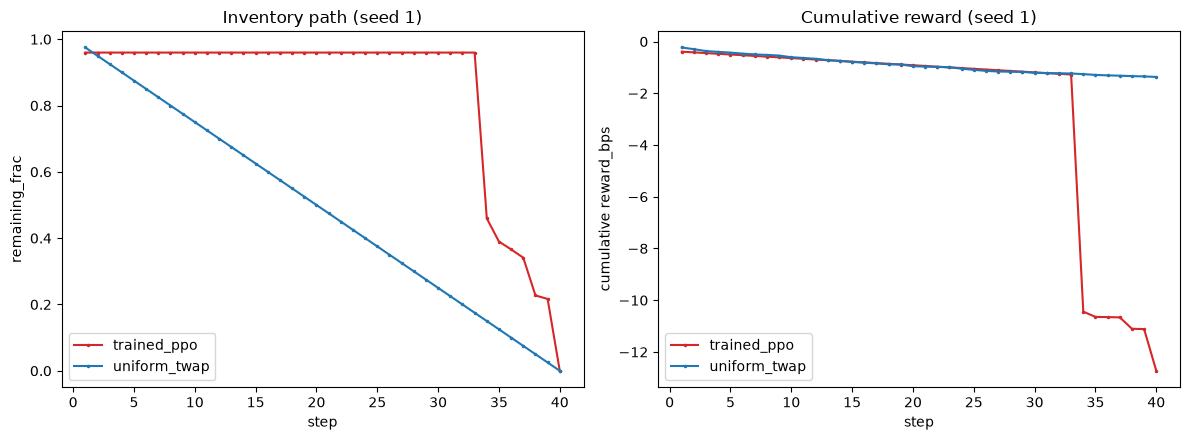

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, color in [("trained_ppo", "tab:red"), ("uniform_twap", "tab:blue")]:
    ep = schedule_results[name][0]  # seed 1
    steps = [s["step"] for s in ep["per_step"]]
    rem = [s["remaining_frac"] for s in ep["per_step"]]
    cum_reward = np.cumsum([s["reward"] for s in ep["per_step"]])
    axes[0].plot(steps, rem, label=name, color=color, marker=".", markersize=3)
    axes[1].plot(steps, cum_reward, label=name, color=color, marker=".", markersize=3)

axes[0].set_xlabel("step"); axes[0].set_ylabel("remaining_frac"); axes[0].set_title("Inventory path (seed 1)")
axes[0].legend()
axes[1].set_xlabel("step"); axes[1].set_ylabel("cumulative reward_bps"); axes[1].set_title("Cumulative reward (seed 1)")
axes[1].legend()
plt.tight_layout()


The trained policy's inventory stays essentially flat (~0.96) for the first 30+
steps, then cliffs down at the very end — the terminal forced-sweep step alone
(`reward≈-1.6` on this seed) is worse than `uniform_twap`'s *entire 40-step episode*
(`total_reward≈-1.4`). `uniform_twap`'s inventory decays smoothly and its cumulative
reward stays close to flat the whole way, with no single catastrophic step.

**This is a genuine PPO optimization/exploration failure for the continuous action
space, not evidence the reward needs redesigning.** The reward function, properly
analyzed over the full trajectory rather than one step at a time, already strongly
prefers what a trivial scripted policy does for free. The earlier "reward structurally
favors holding" hypothesis — built on a one-step marginal argument — doesn't survive
this end-to-end empirical test and should be retired as an explanation for this
specific collapse.

## v3 Results (interim)

- Continuous action space is implementable correctly (`Box(-1,1)` + affine rescale is
  the right fix for the SB3 Gaussian-policy scale mismatch; verified both by the std
  metric and the action-distribution check).
- The trained continuous-action policy still collapses to a severe "hold almost the
  whole episode, then dump late" pattern — worse than any discrete version's collapse.
- This is **not** the reward function's fault: a full-trajectory counterfactual
  comparison shows a trivial uniform (TWAP-like) schedule beats the trained policy by
  roughly 9 reward units on the same seeds, and beats it via both reward components
  (lower cumulative inventory penalty *and* lower slippage/terminal cost). The reward
  already strongly prefers smooth trading; the trained policy simply hasn't found that
  region of policy space.
- Checkpoint selection and the K=30 benchmark are deliberately **not** run yet — there
  is no reason to spend that budget comparing a policy already shown to be
  reward-suboptimal against TWAP/POV/discrete baselines.

## v3 Caveats / Open Questions

- **Why does continuous-action PPO converge here when the reward clearly disfavors it?**
  Candidates not yet tested: entropy bonus specifically for a Gaussian policy (v2.1's
  `ent_coef` sweep was entirely on the categorical/discrete policy — a Gaussian
  policy's entropy dynamics, and how a bonus interacts with its evolving std, are
  untested for this action space); training budget (1000 episodes may simply be too
  few for a continuous policy to escape this basin); policy-network initialization
  specific to continuous control.
- The still-unresolved training-infrastructure wall-clock variability documented in
  v2/v2.1 was not observed this round (~66.6min, no hang), but remains unexplained and
  should still be budgeted for in any future training run on this codebase.
- The previously-flagged "time-scaled urgency penalty" reward change
  (`r_inv = -phi·i_t²·elapsed_frac`) remains an open, isolated candidate, but this
  round's finding weakens the case for it specifically as a fix for this collapse —
  the current reward doesn't appear to need it to prefer smooth trading.